In [ ]:
#1. kiểm tra kết quả assemble_txn.py
import pyarrow.parquet as pq
import pandas as pd, numpy as np, gc
data_dir  = "dataset_high"
tx_path   = f"{data_dir}/transaction_features.parquet"
asof_path = f"{data_dir}/node_edge_features.parquet"
label     = "Is Laundering"
key_cols  = ["src", "dest"]
leak      = ["is_mule", "is_edge_mule"]
def feat_cols(path, drop):
    return [c for c in pq.ParquetFile(path).schema_arrow.names if c not in drop]
def main():
    tx_cols   = feat_cols(tx_path,   set(key_cols + [label, "split"]))
    asof_cols = feat_cols(asof_path, {"split", "ori_idx"})
    dup = sorted(set(tx_cols) & set(asof_cols))
    if dup: raise AssertionError(f"trùng tên cột giữa hai file: {dup}")
    bad = [c for c in leak if c in tx_cols or c in asof_cols]
    if bad: raise AssertionError(f"cột suy từ nhãn lọt vào feature: {bad}")
    meta_tx = pd.read_parquet(tx_path,   columns=[label, "split"])
    meta_asof = pd.read_parquet(asof_path, columns=["split"])
    if len(meta_tx) != len(meta_asof):
        raise AssertionError(f"số dòng lệch: {len(meta_tx):,} vs {len(meta_asof):,}")
    n_bad = int((meta_tx["split"].values != meta_asof["split"].values).sum())
    if n_bad: raise AssertionError(f"{n_bad:,} dòng lệch 'split'")
    del meta_asof; gc.collect()
    y=meta_tx[label].to_numpy(dtype="int8")
    split = meta_tx["split"].to_numpy()
    n=len(y)
    del meta_tx; gc.collect()
    print(f"[align] {n:,} dòng khớp thứ tự")
    names = tx_cols + asof_cols
    X = np.empty((n, len(names)), dtype="float32")
    j = 0
    for path, cols in ((tx_path, tx_cols), (asof_path, asof_cols)):
        pf = pq.ParquetFile(path)
        for c in cols:
            v = pf.read(columns=[c]).column(0).to_numpy(zero_copy_only=False)
            v = v.astype("float32", copy=False)
            if not np.isfinite(v).all():
                raise AssertionError(f"NaN/inf ở cột: {c}")
            X[:, j] = v; j += 1
            del v
        del pf; gc.collect()
    print(f"[build] {len(tx_cols)} tx + {len(asof_cols)} as-of = {j} feature, không NaN/inf")
    return X,y, split, names
X, y, split, names = main()
    

[align] 5,078,345 dòng khớp thứ tự
[build] 32 tx + 63 as-of = 95 feature, không NaN/inf


In [ ]:
#2. kiểm tra tỉ lệ mất cân bằng giữa các lớp 
import pandas as pd
df = pd.read_csv("dataset_high/HI-Small_Trans_split_index.csv")
for s in ["train", "val", "test"]:
    sub = df[df["split"] == s]
    n = len(sub)
    pos = int(sub["Is Laundering"].sum())
    rate = pos / n * 100
    ratio = (n - pos) / pos
    print(f"{s:5s}  n={n:>10,}  pos={pos:>5,}  {rate:.4f}%   neg/pos = {ratio:>6.1f}")

train  n= 3,046,861  pos=2,297  0.0754%   neg/pos = 1325.5
val    n= 1,015,602  pos=1,082  0.1065%   neg/pos =  937.6
test   n= 1,015,882  pos=1,798  0.1770%   neg/pos =  564.0


In [8]:
#3,4. tính scale pos weight (neg/pos)
import json, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from metrics import find_best_threshold, evaluate
warnings.filterwarnings("ignore")

DATA_DIR = "dataset_high"
SUB      = 800_000        

def load(split, n_tail=None):
    df = pd.read_parquet(f"{DATA_DIR}/txn_matrix_{split}_sexoa.parquet")
    if n_tail: df = df.iloc[-n_tail:]
    y = df.pop("Is Laundering").to_numpy()
    return df.to_numpy("float32"), y

X_tr, y_tr = load("train", SUB)
X_va, y_va = load("val")
sc = StandardScaler().fit(X_tr)
X_tr_s, X_va_s = sc.transform(X_tr), sc.transform(X_va)
SPW = (y_tr == 0).sum() / y_tr.sum()

print(f"sweep-train {X_tr.shape} pos={y_tr.sum()} ({y_tr.mean()*100:.4f}%)")
print(f"val         {X_va.shape} pos={y_va.sum()} ({y_va.mean()*100:.4f}%)")
print(f"scale_pos_weight đầy đủ = {SPW:.0f}")

sweep-train (800000, 95) pos=813 (0.1016%)
val         (1015602, 95) pos=1082 (0.1065%)
scale_pos_weight đầy đủ = 983


In [9]:
#3,4 định nghĩa hàm các hàm để check tune config [build(tên model, params, seed), boundary_table() tune giá trị cho từng tham số] 
SCALED = {"lr", "mlp"}
def build(name, p, seed=0):
    if name == "lr":  return LogisticRegression(**p, random_state=seed)
    if name == "dt":  return DecisionTreeClassifier(**p, random_state=seed)
    if name == "rf":  return RandomForestClassifier(**p, random_state=seed)
    if name == "mlp": return MLPClassifier(**p, random_state=seed)
    if name == "xgb": return XGBClassifier(**p, random_state=seed, eval_metric="aucpr")

rows = []
def run(name, params, factor, value, seed=0, Xa=None, ya=None):
    A, B = (X_tr_s, X_va_s) if name in SCALED else (X_tr, X_va)
    if Xa is not None: A = Xa
    yy = y_tr if ya is None else ya
    m = build(name, params, seed); t0 = time.time()
    m.fit(A, yy, eval_set=[(B, y_va)], verbose=False) if name == "xgb" else m.fit(A, yy)
    fit_s = time.time() - t0
    s = m.predict_proba(B)[:, 1]
    e = evaluate(y_va, s, find_best_threshold(y_va, s))
    nt = int(m.best_iteration) + 1 if name == "xgb" else None
    rows.append({"model": name, "factor": factor, "value": str(value), "seed": seed,
                 "f1": e["f1_minority"], "pr_auc": e["pr_auc"], "recall": e["recall"],
                 "precision": e["precision"], "fit_s": round(fit_s, 1), "n_trees": nt,
                 "params": json.dumps(params, default=str)})
    print(f"  {factor}={str(value):<18} f1={e['f1_minority']*100:5.2f} "
          f"pr_auc={e['pr_auc']*100:5.2f}"
          f"{'' if nt is None else f' cay={nt:>4}'} ({fit_s:.0f}s)", flush=True)

def boundary_table(rows, grids):
    ev = pd.DataFrame(rows); out = []
    for (mdl, fac), grid in grids.items():
        sub = ev[(ev.model == mdl) & (ev.factor == fac)]
        if sub.empty: continue
        vals = list(sub.value); best = sub.loc[sub.f1.idxmax(), "value"]
        out.append({"model": mdl, "sieu_tham_so": fac, "quet": vals, "toi_uu": best,
                    "co_trong_GRIDS": best in [str(g) for g in grid],
                    "khong_cham_bien": vals.index(best) not in (0, len(vals) - 1)})
    return pd.DataFrame(out)

In [ ]:
# 3. lr: độ "balanced" ảnh hưởng đến F1, cw: class weight
print("--- lr: n_iter_ vs max_iter ---")
for cw in [None, "balanced"]:
    for mi in [1000, 3000]:
        m = LogisticRegression(C=1.0, class_weight=cw, max_iter=mi, random_state=0)
        t0 = time.time(); m.fit(X_tr_s, y_tr); el = time.time() - t0
        s = m.predict_proba(X_va_s)[:, 1]
        e = evaluate(y_va, s, find_best_threshold(y_va, s))
        n_it = int(m.n_iter_[0])
        print(f"  cw={str(cw):<9} max_iter={mi:<5} n_iter_={n_it:<5} "
              f"hoi_tu={n_it < mi!s:<5} f1={e['f1_minority']*100:5.2f} ({el:.0f}s)")

--- lr: n_iter_ vs max_iter ---
  cw=None      max_iter=1000  n_iter_=22    hoi_tu=True  f1=48.98 (2s)
  cw=None      max_iter=3000  n_iter_=22    hoi_tu=True  f1=48.98 (1s)
  cw=balanced  max_iter=1000  n_iter_=526   hoi_tu=True  f1=35.19 (24s)
  cw=balanced  max_iter=3000  n_iter_=526   hoi_tu=True  f1=35.19 (30s)


In [6]:
#3 early stopping của mlp có bị sai không
print(f"accuracy của model toàn 0 = {(y_tr == 0).mean():.6f}\n")
MAX_ITER = 15
for es in [True, False]:
    for seed in range(3):
        m = MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1e-4, batch_size=512,
                          max_iter=MAX_ITER, early_stopping=es, random_state=seed)
        m.fit(X_tr_s, y_tr)
        s = m.predict_proba(X_va_s)[:, 1]
        e = evaluate(y_va, s, find_best_threshold(y_va, s))
        print(f"  es={es!s:<5} seed={seed}  n_iter_={m.n_iter_:<3} "
              f"f1_val={e['f1_minority']*100:5.2f}")
        if es and m.n_iter_ < MAX_ITER:
            print(f"      => early stopping ĐÃ kích hoạt (dừng ở {m.n_iter_}/{MAX_ITER} iter)")
            print(f"      acc nội bộ : {[round(v, 6) for v in m.validation_scores_]}")
        else:
            print(f"      => early stopping KHÔNG kích hoạt (chạy hết {m.n_iter_}/{MAX_ITER} iter)")
        print(f"      loss_curve : {[round(v, 5) for v in m.loss_curve_]}")


accuracy của model toàn 0 = 0.998984

  es=True  seed=0  n_iter_=12  f1_val=47.50
      => early stopping ĐÃ kích hoạt (dừng ở 12/15 iter)
      acc nội bộ : [0.99915, 0.999175, 0.999212, 0.999212, 0.999212, 0.999275, 0.999162, 0.99925, 0.999238, 0.999225, 0.999263, 0.999238]
      loss_curve : [np.float64(0.00911), np.float64(0.0037), np.float64(0.00346), np.float64(0.00333), np.float64(0.00322), np.float64(0.0031), np.float64(0.00307), np.float64(0.00297), np.float64(0.00294), np.float64(0.00285), np.float64(0.00275), np.float64(0.00274)]
  es=True  seed=1  n_iter_=12  f1_val=53.12
      => early stopping ĐÃ kích hoạt (dừng ở 12/15 iter)
      acc nội bộ : [0.999238, 0.99925, 0.999287, 0.999275, 0.999287, 0.999325, 0.999287, 0.999325, 0.999175, 0.9993, 0.999263, 0.999287]
      loss_curve : [np.float64(0.01373), np.float64(0.00373), np.float64(0.00348), np.float64(0.00336), np.float64(0.00326), np.float64(0.00313), np.float64(0.00308), np.float64(0.00298), np.float64(0.00289), np.flo

In [7]:
# 3. độ phân giải cho mô hình cây
print("--- dt---")
for d in [8, 12, 16, 20, None]:
    m = DecisionTreeClassifier(max_depth=d, class_weight="balanced",
                               random_state=0).fit(X_tr, y_tr)
    s = m.predict_proba(X_va)[:, 1]
    e = evaluate(y_va, s, find_best_threshold(y_va, s))
    print(f"  độ sâu dt {str(d):<5} n_la={m.get_n_leaves():>8,}  "
          f"Số giá trị dự đoán xác suất khác nhau {len(np.unique(s)):>6}  f1={e['f1_minority']*100:5.2f}")

print("--- rf---")
for n in [10, 100]:
    m = RandomForestClassifier(n_estimators=n, max_depth=None, class_weight="balanced",
                               n_jobs=-1, random_state=0).fit(X_tr, y_tr)
    s = m.predict_proba(X_va)[:, 1]
    e = evaluate(y_va, s, find_best_threshold(y_va, s))
    print(f"  rf n_cay={n:<4} depth=None    Số giá trị dự đoán xác suất khác nhau {len(np.unique(s)):>6}  "
          f"f1={e['f1_minority']*100:5.2f}")

--- dt---
  độ sâu dt 8     n_la=      56  Số giá trị dự đoán xác suất khác nhau     12  f1=55.00
  độ sâu dt 12    n_la=     130  Số giá trị dự đoán xác suất khác nhau     14  f1=54.99
  độ sâu dt 16    n_la=     213  Số giá trị dự đoán xác suất khác nhau     12  f1=49.29
  độ sâu dt 20    n_la=     292  Số giá trị dự đoán xác suất khác nhau     14  f1=10.36
  độ sâu dt None  n_la=   1,834  Số giá trị dự đoán xác suất khác nhau      2  f1= 5.70
--- rf---
  rf n_cay=10   depth=None    Số giá trị dự đoán xác suất khác nhau     11  f1=50.59
  rf n_cay=100  depth=None    Số giá trị dự đoán xác suất khác nhau     79  f1=57.28


In [8]:
# 3. giá trị max depth cho dt
for n_tail in [200_000, 400_000, 800_000]:
    Xs, ys = X_tr[-n_tail:], y_tr[-n_tail:]
    line, best = [], (None, -1)
    for d in [6, 8, 10, 12, 16, 20]:
        m = DecisionTreeClassifier(max_depth=d, class_weight="balanced",
                                   random_state=0).fit(Xs, ys)
        s = m.predict_proba(X_va)[:, 1]
        f1 = evaluate(y_va, s, find_best_threshold(y_va, s))["f1_minority"]
        line.append(f"d{d}:{f1*100:5.1f}")
        if f1 > best[1]: best = (d, f1)
    print(f"  n={n_tail:>9,}  " + "  ".join(line) + f"-> tốt nhất d={best[0]}")

  n=  200,000  d6: 25.8  d8: 40.1  d10:  8.3  d12: 17.7  d16:  8.2  d20:  6.6-> tốt nhất d=8
  n=  400,000  d6:  9.1  d8: 55.2  d10: 55.7  d12: 10.8  d16:  9.5  d20:  9.7-> tốt nhất d=10
  n=  800,000  d6: 53.6  d8: 55.0  d10: 54.6  d12: 55.0  d16: 49.3  d20: 10.4-> tốt nhất d=8


In [9]:
# 3. xgb: KHONG dung run() vi run() cho xgb early-stop tren val (= tap cham diem).
#    O day tach 10% duoi train lam ES, dung nhu ES_FRAC trong train_classical.py
cut = int(len(y_tr) * 0.9)
Xf, yf, Xe, ye = X_tr[:cut], y_tr[:cut], X_tr[cut:], y_tr[cut:]
BASE = dict(max_depth=8, learning_rate=0.05, n_estimators=1000,
            early_stopping_rounds=20, subsample=0.8, colsample_bytree=0.8,
            tree_method="hist", n_jobs=-1, eval_metric="aucpr")

def xgb_probe(tag, **over):
    f1s, nt = [], 0
    for seed in range(3):
        m = XGBClassifier(**BASE, **over, random_state=seed)
        m.fit(Xf, yf, eval_set=[(Xe, ye)], verbose=False)
        s = m.predict_proba(X_va)[:, 1]
        f1s.append(evaluate(y_va, s, find_best_threshold(y_va, s))["f1_minority"])
        nt = m.best_iteration + 1
    print(f"  {tag:<22} f1={np.mean(f1s)*100:5.2f} +/- {np.std(f1s, ddof=1)*100:4.2f}"
          f"cây sau khi early stopping: {nt:>4}")

print("--- scale_pos_weight---")
for spw in [1, 5, 10, 20, 50]:
    xgb_probe(f"spw={spw}", scale_pos_weight=spw)

print("--- regulation lambda (L2)---")
for lam in [0.1, 1.0, 10.0, 100.0]:
    xgb_probe(f"lambda={lam}", scale_pos_weight=10, reg_lambda=lam)

--- scale_pos_weight---
  spw=1                  f1=62.48 +/- 1.74cây sau khi early stopping:  101
  spw=5                  f1=62.08 +/- 0.54cây sau khi early stopping:  134
  spw=10                 f1=60.93 +/- 0.25cây sau khi early stopping:  193
  spw=20                 f1=60.77 +/- 1.40cây sau khi early stopping:  252
  spw=50                 f1=60.19 +/- 1.02cây sau khi early stopping:  211
--- regulation lambda (L2)---
  lambda=0.1             f1=60.42 +/- 0.76cây sau khi early stopping:  150
  lambda=1.0             f1=60.93 +/- 0.25cây sau khi early stopping:  193
  lambda=10.0            f1=61.37 +/- 0.19cây sau khi early stopping:  154
  lambda=100.0           f1=59.76 +/- 0.55cây sau khi early stopping:  172


In [10]:
# 3. tham số thay thế
print("--- rf: min_samples_leaf, max_depth=None ---")
for n in [100, 300]:
    for l in [1, 5, 20]:
        run("rf", {"n_estimators": n, "max_depth": None, "min_samples_leaf": l,
                   "class_weight": "balanced", "n_jobs": -1},
            f"rf_n{n}", f"leaf={l}")

--- rf: min_samples_leaf, max_depth=None ---
  rf_n100=leaf=1             f1=57.28 pr_auc=46.92 (24s)
  rf_n100=leaf=5             f1=58.18 pr_auc=51.96 (23s)
  rf_n100=leaf=20            f1=55.81 pr_auc=52.14 (22s)
  rf_n300=leaf=1             f1=57.04 pr_auc=46.95 (72s)
  rf_n300=leaf=5             f1=58.80 pr_auc=53.01 (65s)
  rf_n300=leaf=20            f1=56.37 pr_auc=52.75 (70s)


b=2
SE = 0.00  f1_mean = 40.99
idx best config = 2 (f1_mean=40.99)   chạm biên grid
  best config -> {'C': 1.0, 'class_weight': None, 'max_iter': 1000}

b=1
SE = 0.07  f1_mean = 55.12
idx best config = 1 (f1_mean=55.19)
  best config -> {'max_depth': 16, 'class_weight': 'balanced'}

b=5
SE = 0.38  f1_mean = 58.87
idx best config = 5 (f1_mean=59.26)   chạm biên grid
  best config -> {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1, 'class_weight': 'balanced', 'n_jobs': -1}

b=7
SE = 0.30  f1_mean = 62.99
idx best config = 4 (f1_mean=63.13)
  best config -> {'max_depth': 8, 'learning_rate': 0.05, 'scale_pos_weight': 5, 'reg_lambda': 1.0, 'n_estimators': 1000, 'early_stopping_rounds': 20, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'n_jobs': -1}

b=0
SE = 1.29  f1_mean = 54.64
idx best config = 0 (f1_mean=55.93)   chạm biên grid
  best config -> {'hidden_layer_sizes': (64, 32), 'alpha': 0.0001, 'batch_size': 512, 'max_iter': 30, 'early_stopping': False}

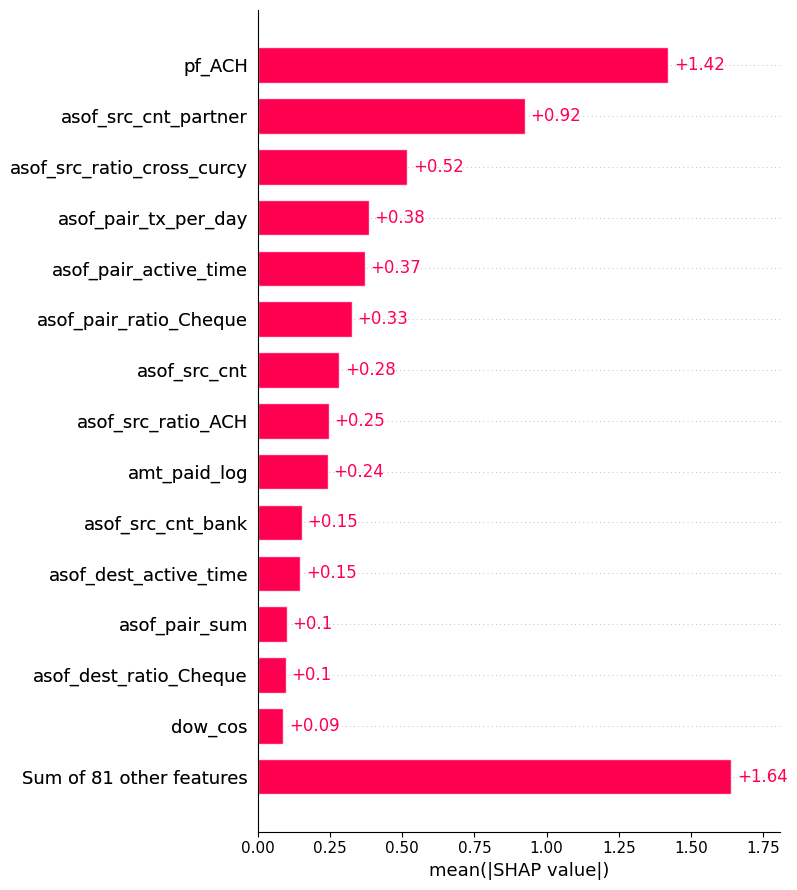

In [10]:
#4. kiểm tra kết quả results
import json, importlib
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import shap
import train_classical as tc
importlib.reload(tc)

SHOW = ("C", "max_depth", "min_samples_leaf", "n_estimators",
        "scale_pos_weight", "reg_lambda", "hidden_layer_sizes")

df = pd.read_csv("results.csv")
df = df[(df.stage == "tune") & (df.split == "val")]
df = df.drop_duplicates(subset=["model", "params", "seed"], keep="last")

all_tables = []
for name, grid in tc.GRIDS.items():
    rows = []
    for cfg in grid:
        f = df[(df.model == name) & (df.params == json.dumps(cfg))].f1_minority
        rows.append({"n_seed": len(f),
                     "f1_mean": f.mean() * 100 if len(f) else np.nan,
                     "f1_sd": f.std(ddof=1) * 100 if len(f) > 1 else np.nan,
                     **{k: v for k, v in cfg.items() if k in SHOW}})
    r = pd.DataFrame(rows)
    r.insert(0, "model", name)
    all_tables.append(r)

    if (r.n_seed < 2).any():
        continue
    se = r.f1_sd / np.sqrt(r.n_seed)
    b = int(r.f1_mean.idxmax())
    cutoff = r.f1_mean[b] - se[b]
    pick = int(next(i for i, m in enumerate(r.f1_mean) if m >= cutoff))
    print(f"b={b}")
    print(f"SE = {se[b]:.2f}  f1_mean = {cutoff:.2f}")
    print(f"idx best config = {pick} (f1_mean={r.f1_mean[pick]:.2f})"
          f"{'   chạm biên grid' if b in (0, len(grid) - 1) else ''}")
    print(f"  best config -> {tc.pick_best(name)}\n")
pd.concat(all_tables, ignore_index=True).to_csv("config_1.csv", index=False)

def per_axis(name, axes):
    d = df[df.model == name].reset_index(drop=True)
    p = d.params.apply(json.loads).apply(pd.Series)
    d = pd.concat([d[["f1_minority"]], p[axes]], axis=1)
    print(f"--- {name}: ")
    for a in axes:
        other = [x for x in axes if x != a]
        t = d.pivot_table(index=other, columns=a, values="f1_minority", aggfunc="mean")
        print((t * 100).round(2).to_string(), "\n")
# per_axis("rf",  ["n_estimators", "min_samples_leaf"])
# per_axis("xgb", ["reg_lambda", "scale_pos_weight"])
feat_names = [c for c in pq.ParquetFile("dataset_high/txn_matrix_val.parquet")
              .schema_arrow.names if c != "Is Laundering"]
xgb_model = tc.XGBClassifier()
xgb_model.load_model("models/xgboost_seed0.json")
rng = np.random.RandomState(0)
idx = rng.choice(len(X_va), size=5000, replace=False)
X_shap = X_va[idx]
explainer=shap.TreeExplainer(xgb_model)
exp=explainer(X_shap)
exp.feature_names=feat_names
y_shap=y_va[idx]
fraud=np.where(y_shap)
i=fraud[0]
shap.plots.bar(exp[i],max_display=15,show=False)
plt.tight_layout()
plt.show()


In [ ]:
#5. chỉ thực nghiệm bổ sung tìm kết quả tốt nhất
import json, time, gc, importlib
import numpy as np, pandas as pd
import train_classical as tc
from metrics import find_best_threshold, evaluate, log_result
importlib.reload(tc)                      

done = pd.read_csv("results.csv")
done = done[(done.model == "xgb") & (done.stage == "tune") & (done.split == "val")]
todo = [c for c in tc.GRIDS["xgb"] if json.dumps(c) not in set(done.params)]
print(f"cần chạy thêm {len(todo)} config xgb:")
for c in todo:
    print("   ", {k: c[k] for k in ("scale_pos_weight", "reg_lambda")})

def load_full(split):
    df = pd.read_parquet(f"dataset_high/txn_matrix_{split}.parquet")
    y = df.pop("Is Laundering").to_numpy()
    return df.to_numpy("float32"), y

Xtr, ytr = load_full("train")
Xva, yva = load_full("val")
print("full train", Xtr.shape, "| val", Xva.shape)

for cfg in todo:
    print(f"--- spw={cfg['scale_pos_weight']} lambda={cfg['reg_lambda']} ---")
    for seed in tc.TUNE_SEEDS:
        m = tc.build_model("xgb", seed, None, cfg)   
        t0 = time.time()
        tc.fit(m, "xgb", Xtr, ytr)                   
        el = round(time.time() - t0, 1)
        s = m.predict_proba(Xva)[:, 1]
        e = evaluate(yva, s, find_best_threshold(yva, s))
        log_result("xgb", "val", e, seed=seed, stage="tune",
                   train_time_s=el, params=json.dumps(cfg))
        print(f"  seed={seed} f1={e['f1_minority']*100:5.2f} "
              f"cây={m.best_iteration + 1} ({el:.0f}s)")

del Xtr, ytr, Xva, yva; gc.collect()

can chay them 3 config xgb:
    {'scale_pos_weight': 1, 'reg_lambda': 0.1}
    {'scale_pos_weight': 5, 'reg_lambda': 0.1}
    {'scale_pos_weight': 10, 'reg_lambda': 0.1}
full train (3046861, 95) | val (1015602, 95)
--- spw=1 lambda=0.1 ---
[0]	validation_0-aucpr:0.12986
[1]	validation_0-aucpr:0.20433
[2]	validation_0-aucpr:0.23502
[3]	validation_0-aucpr:0.25633
[4]	validation_0-aucpr:0.28522
[5]	validation_0-aucpr:0.30616
[6]	validation_0-aucpr:0.32553
[7]	validation_0-aucpr:0.33088
[8]	validation_0-aucpr:0.34263
[9]	validation_0-aucpr:0.35479
[10]	validation_0-aucpr:0.36049
[11]	validation_0-aucpr:0.36545
[12]	validation_0-aucpr:0.37236
[13]	validation_0-aucpr:0.37917
[14]	validation_0-aucpr:0.38600
[15]	validation_0-aucpr:0.39452
[16]	validation_0-aucpr:0.40574
[17]	validation_0-aucpr:0.41487
[18]	validation_0-aucpr:0.41922
[19]	validation_0-aucpr:0.42759
[20]	validation_0-aucpr:0.43438
[21]	validation_0-aucpr:0.44381
[22]	validation_0-aucpr:0.44952
[23]	validation_0-aucpr:0.45449
[2

2207

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")
metrics = ["f1_minority", "precision", "recall", "pr_auc",
           "recall@fpr1%", "precision@1000"]

agg = df.groupby(["model", "split"])[metrics].agg(["mean", "std"]).round(4)
agg

f1_minority         precision          recall          pr_auc  \
                   mean     std      mean     std    mean     std    mean   
model split                                                                 
dt    test       0.6215  0.0192    0.7237  0.0511  0.5457  0.0067  0.4359   
      val        0.5561  0.0168    0.7163  0.0496  0.4558  0.0163  0.3707   
lr    test       0.4291  0.0000    0.3730  0.0000  0.5050  0.0000  0.4622   
      val        0.3301  0.0000    0.3038  0.0000  0.3614  0.0000  0.2913   
mlp   test       0.7033  0.0115    0.7995  0.0394  0.6289  0.0195  0.7044   
      val        0.6313  0.0077    0.8263  0.0280  0.5111  0.0074  0.5956   
rf    test       0.6923  0.0016    0.8887  0.0077  0.5671  0.0049  0.6855   
      val        0.5308  0.1522    0.6794  0.2720  0.4495  0.0756  0.4942   
xgb   test       0.7386  0.0000    0.9203  0.0000  0.6168  0.0000  0.7298   
      val        0.6500  0.0213    0.8829  0.0467  0.5153  0.0229  0.6089   

                    recall@fpr1%         precision@1000          
                std         mean     std           mean     std  
model split                                                      
dt    test   0.0322       0.7761  0.0050         0.6480  0.0925  
      val    0.0300       0.7535  0.0269         0.5132  0.0217  
lr    test   0.0000       0.7764  0.0000         0.6190  0.0000  
      val    0.0000       0.7468  0.0000         0.3320  0.0000  
mlp   test   0.0129       0.8773  0.0079         0.9176  0.0235  
      val    0.0107       0.8257  0.0046         0.6006  0.0102  
rf    test   0.0010       0.8343  0.0041         0.9252  0.0016  
      val    0.1485       0.7978  0.0144         0.5129  0.1371  
xgb   test   0.0000       0.8804  0.0000         0.9500  0.0000  
      val    0.0311       0.8200  0.0146         0.6125  0.0256